# 🧠 Workplace Mental Health & Productivity – OSMI Dataset (Capstone Project)

# 🚀 Executive Summary: Mental Health in the Tech Workplace (OSMI Capstone)

## 📌 Project Overview  
This capstone project analyzes the OSMI (Open Sourcing Mental Illness) Mental Health in Tech Survey dataset to explore mental health trends, stigma, and workplace support structures. The analysis is designed for Genpact, with the aim of improving workplace mental wellness culture and identifying key areas where interventions can drive productivity and psychological safety.

## 🎯 Objectives  
- Quantify openness toward discussing mental health at work  
- Measure the availability and effectiveness of organizational mental health services  
- Explore patterns in gender, company size, remote work, and their relation to treatment-seeking behavior  
- Investigate whether workplace culture impacts employee mental health or productivity  

## 🔍 Key Insights  
- 🧠 Only 20% of employees showed “High Openness” toward discussing mental health at work. The majority fall into “Moderate” or “Low” categories, often unsure about discussing with coworkers or supervisors.  
- 🧑‍⚕️ Employees with “High Services Support” (access to benefits, leave, wellness programs) are more likely to report “No Work Interference” due to mental health.  
- 👩 Women were more likely to seek mental health treatment than men, while men were less likely to disclose struggles at work.  
- 🏢 Employees in small companies (<100 employees) face significantly less formal support and show higher work interference.  
- 🌍 Remote employees report slightly better mental health openness than non-remote employees, potentially due to increased flexibility.  

## ✅ Business Recommendations  
- Introduce or improve anonymous wellness programs and mental health benefits  
- Train managers to foster psychologically safe conversations  
- Normalize discussions around mental health in small to mid-sized teams  
- Monitor mental health openness as a KPI linked to engagement and attrition  



---


## 📂 Dataset Overview
- **Source**: Open Sourcing Mental Illness (OSMI) survey dataset
- **Records**: ~1,200 survey responses from employees in the tech industry
- **Key Features**:
  - Company type, company size
  - Supervisor support, benefits, wellness programs
  - Work interference due to mental health
- **Objective**: Understand how organizational factors affect mental health and work performance.


## 🧹 Data Cleaning Summary
- Removed missing and irrelevant values in critical columns
- Standardized categorical variables (e.g., Yes/No, company size buckets)
- Created derived columns:
  - `mental_health_status` (to flag reported mental health issues)
  - `company_openness_flag` (to measure company openness to discussions)


## 📊 Exploratory Data Analysis (EDA)

This section explores the cleaned dataset to uncover patterns and relationships.


In [3]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
plt.rcParams['figure.figsize']=(6,4)

**Loading the cleaned osmi tech dataset for data analysis.

In [4]:
tech=pd.read_csv('cleaned_osmi_tech.csv')

In [5]:
tech.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Age_Group
0,37.0,female,No,No,Yes,Often,6-25,No,Yes,Yes,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,31-40
1,32.0,male,No,No,No,Rarely,6-25,No,Yes,No,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,31-40
2,31.0,male,No,Yes,Yes,Often,26-100,No,Yes,No,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,31-40
3,31.0,male,No,No,No,Never,100-500,Yes,Yes,Yes,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,31-40
4,33.0,male,No,Yes,No,Sometimes,6-25,No,Yes,Yes,...,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,31-40


In [4]:
tech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1025 non-null   float64
 1   Gender                     1025 non-null   object 
 2   self_employed              1025 non-null   object 
 3   family_history             1025 non-null   object 
 4   treatment                  1025 non-null   object 
 5   work_interfere             1025 non-null   object 
 6   no_employees               1025 non-null   object 
 7   remote_work                1025 non-null   object 
 8   tech_company               1025 non-null   object 
 9   benefits                   1025 non-null   object 
 10  care_options               1025 non-null   object 
 11  wellness_program           1025 non-null   object 
 12  seek_help                  1025 non-null   object 
 13  anonymity                  1025 non-null   objec

#  Column Types
**Numerical -** Age,
**Categorical-** Gender,self_employed,family_hostory,treatment,work_interfere,no_employees,remote_work,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Age_Group
 

##  The eda and insights we are gonna find out from this dataset are:
**The aim of this project is to analyze gender-based differences in mental health among tech industry professionals using the OSMI Mental Health dataset. Specifically, the project explores:
Whether mental health issues interfere with work differently for different genders
If openness (discussing mental health with coworkers or supervisors) is associated with reduced mental health impact
Whether the ease of taking leave is related to experiencing mental health challenges
How support systems (family history, care options, benefits) vary across genders and affect outcomes**

We will first analyze gender-based differences in mental health. Key factors to consider include treatment and work interference. For instance, if a person responds 'don’t know' to treatment, they may not currently face mental health issues or may not have sought treatment."

##  we are gonna perform  uinvariate analysis on** **age,gender,family_history,remote_work,leave,work_interfere,benefits,care_options,wellness_program,mental_health_consequences,coworker,supervisor,anonymity

## 1 univariate analysis on treatment and work interfere:

In [5]:
tech['treatment'].value_counts()

treatment
No     515
Yes    510
Name: count, dtype: int64

Text(0.5, 0, 'Treatment Status')

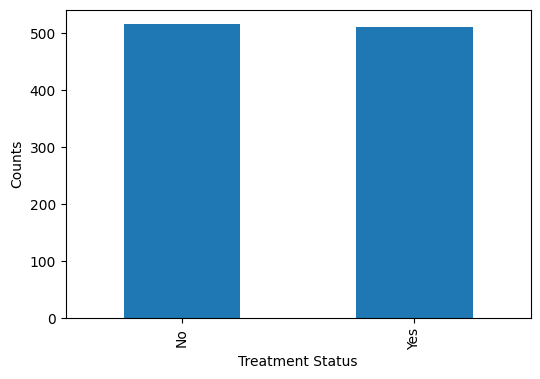

In [6]:
tech['treatment'].value_counts().plot(kind='bar')
plt.ylabel("Counts")
plt.xlabel("Treatment Status")

<Axes: ylabel='count'>

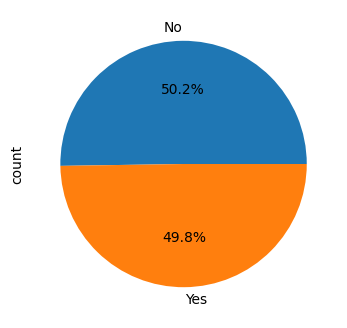

In [6]:
tech['treatment'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# 1.1 conclusion:
“About 50% of respondents reported receiving treatment, suggesting they are more likely to have experienced mental health challenges.”

## 2 univariate analysis on work interfere:

In [8]:
tech['work_interfere'].value_counts()

work_interfere
Sometimes    387
no issue     215
Never        177
Rarely       137
Often        109
Name: count, dtype: int64

Text(0, 0.5, 'Count')

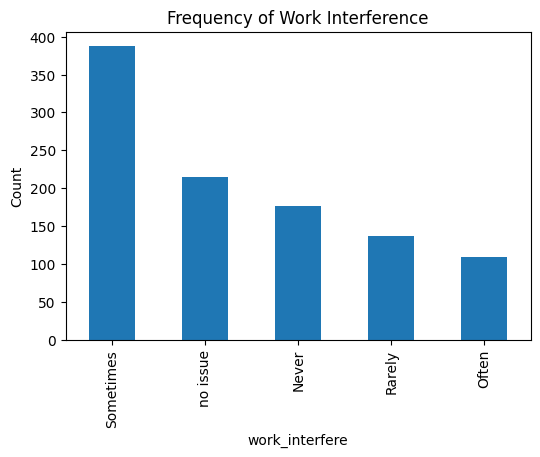

In [9]:
tech['work_interfere'].value_counts().plot(kind='bar')
plt.title("Frequency of Work Interference")
plt.ylabel("Count")

<Axes: ylabel='count'>

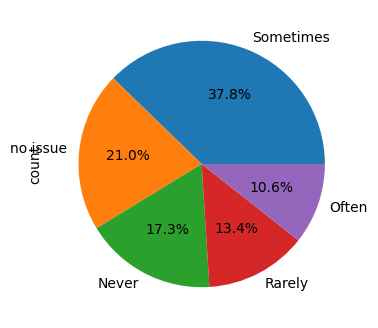

In [10]:
tech['work_interfere'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# 2.1 conclusion :
*“Respondents answering ‘Don’t know’ likely have not experienced mental health issues. We will create a new column, mental_health_status, with values Affected and Not Affected:

If a person answered ‘Yes’ to treatment → Affected

If they responded to work interference as ‘Sometimes’, ‘Rarely’, or ‘Often’ → Affected”*



In [11]:
def mentally_ill(row):
    if row['treatment']=='Yes':
        return 'Yes'   
    elif row['work_interfere']in['Sometimes','Often','Rarely','Never']:
         return 'Yes'
    else :
         return 'No'
tech['mental_health_status']=tech.apply(mentally_ill,axis=1)
    

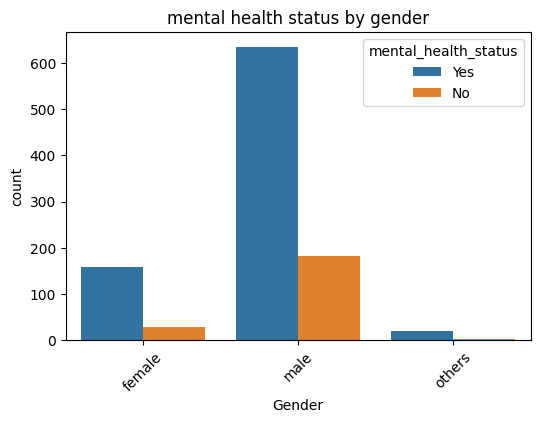

In [12]:
sns.countplot(x='Gender',hue='mental_health_status',data=tech)
plt.title('mental health status by gender')
plt.xticks(rotation=45)
plt.show()

## 3 univariate analysis on Gender:


In [13]:
tech['Gender'].value_counts()

Gender
male      818
female    186
others     21
Name: count, dtype: int64

# 3.1 conclusion:
The dataset is male-dominated (~70% male respondents), reflecting typical gender distribution in the tech industry.

## 4 univariate analysis on Age :


In [14]:
tech['Age'].describe()


count    1025.000000
mean       31.878049
std         7.151114
min        18.000000
25%        27.000000
50%        31.000000
75%        35.000000
max        62.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

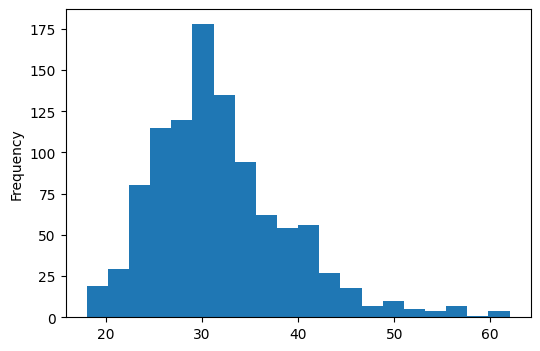

In [15]:
tech['Age'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

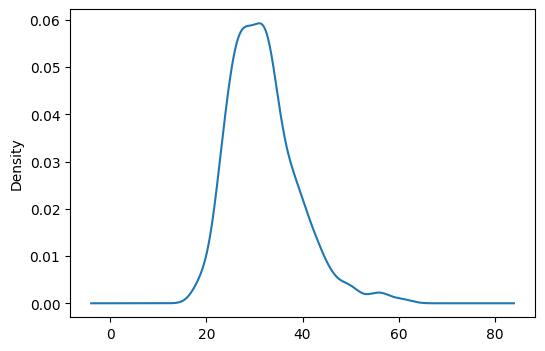

In [16]:
tech['Age'].plot(kind='kde')

In [17]:
tech['Age'].skew()

np.float64(0.9989250433799318)

<Axes: >

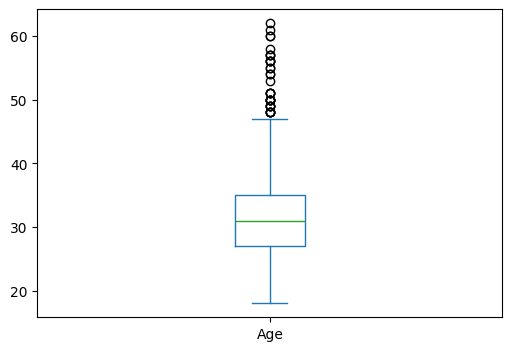

In [18]:
tech['Age'].plot(kind='box')

In [19]:
tech[tech['Age']>45]

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Age_Group,mental_health_status
16,46.0,male,Yes,Yes,No,Sometimes,1-5,Yes,Yes,Yes,...,No,No,Yes,Yes,No,Yes,Yes,Yes,41-65,Yes
20,46.0,male,No,No,Yes,Often,26-100,Yes,Yes,Yes,...,Maybe,No,Some of them,Yes,No,Maybe,No,No,41-65,Yes
34,50.0,male,No,No,No,no issue,100-500,No,Yes,Yes,...,No,No,Some of them,Yes,No,Maybe,Don't know,No,41-65,No
253,56.0,male,No,No,Yes,Never,More than 1000,No,Yes,Yes,...,No,Maybe,Yes,Some of them,No,Maybe,Don't know,No,41-65,Yes
256,60.0,male,No,No,No,no issue,More than 1000,No,Yes,Yes,...,No,No,Some of them,Yes,Maybe,Maybe,Yes,No,41-65,No
286,46.0,male,No,No,No,Never,26-100,No,Yes,Yes,...,No,No,Some of them,Some of them,Maybe,Maybe,Don't know,No,41-65,Yes
296,54.0,male,No,Yes,Yes,Never,More than 1000,No,Yes,Don't know,...,No,No,No,Yes,No,No,Don't know,No,41-65,Yes
315,55.0,male,No,Yes,Yes,Rarely,More than 1000,No,Yes,Yes,...,No,No,Yes,Yes,No,No,Yes,No,41-65,Yes
334,48.0,male,No,No,No,no issue,26-100,No,Yes,Don't know,...,Maybe,Maybe,No,No,No,No,No,No,41-65,No
356,55.0,male,No,Yes,Yes,Sometimes,1-5,Yes,Yes,No,...,Yes,Maybe,No,No,No,No,No,Yes,41-65,Yes


# 4.1 conclusion:
There are many outliers in age column but they dont seem to be invalid as age can vary.

## 5 univariate analysis on self_employed :


In [20]:
tech['self_employed'].value_counts()

self_employed
No     897
Yes    128
Name: count, dtype: int64

Text(0.5, 0, 'Self Employed')

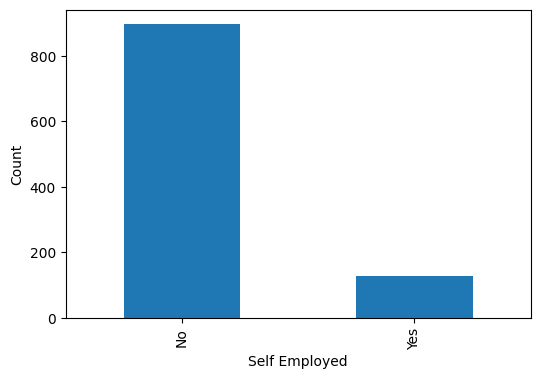

In [21]:
tech['self_employed'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.xlabel("Self Employed")


<Axes: ylabel='count'>

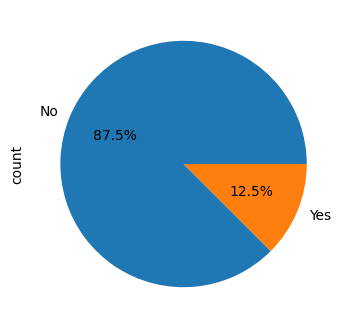

In [22]:
tech['self_employed'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# 5.1 conclusions :
“The number of self-employed individuals is significantly lower compared to non-self-employed individuals.”

## 6 univariate analysis on no_employees :


In [23]:
tech['no_employees'].value_counts()

no_employees
6-25              267
26-100            242
More than 1000    192
1-5               148
100-500           135
500-1000           41
Name: count, dtype: int64

Text(0, 0.5, 'Counts')

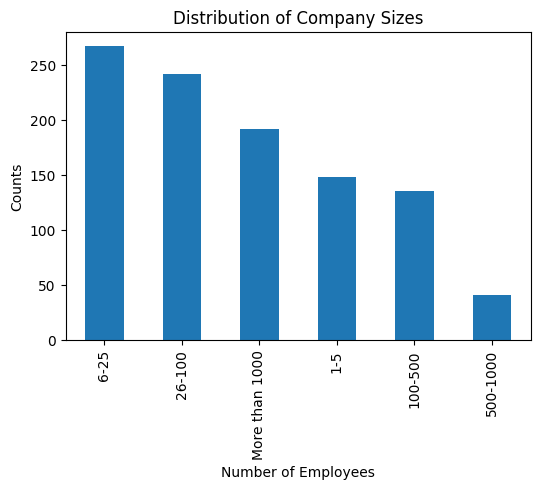

In [24]:
tech['no_employees'].value_counts().plot(kind='bar')
plt.title("Distribution of Company Sizes")
plt.xlabel("Number of Employees")
plt.ylabel("Counts")

<Axes: ylabel='count'>

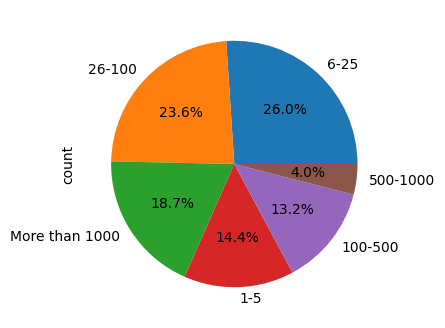

In [25]:
tech['no_employees'].value_counts().plot(kind='pie',autopct='%0.1f%%')


# 6.1 conclusion:
“Most individuals work in companies with 6–25 employees, followed by those in 26–100 employee workplaces.”



## 7 univariate analysis on family_history :

In [26]:
tech['family_history'].value_counts()

family_history
No     636
Yes    389
Name: count, dtype: int64

Text(0.5, 0, 'Family History')

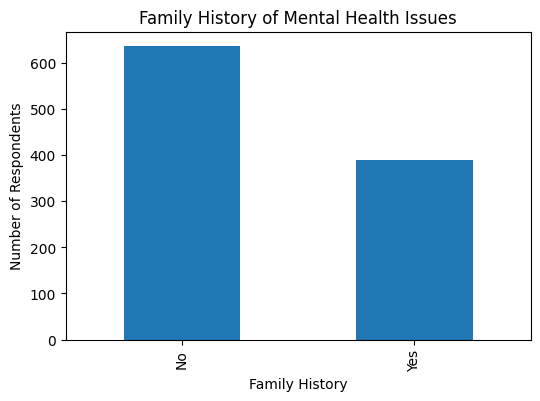

In [27]:
tech['family_history'].value_counts().plot(kind='bar')
plt.title("Family History of Mental Health Issues")
plt.ylabel("Number of Respondents")
plt.xlabel("Family History")

<Axes: ylabel='count'>

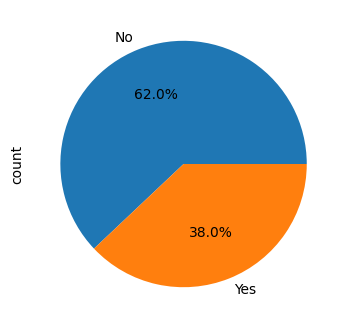

In [28]:
tech['family_history'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# 7.1 conclusion:
Almost 62 percent individuals doesnot have any family history about any mental health issue.

## 8 univariate analysis on leave :


In [29]:
tech['leave'].value_counts()

leave
Don't know            455
Somewhat easy         218
Very easy             176
Somewhat difficult     98
Very difficult         78
Name: count, dtype: int64

*“The leave column has many categories. To reduce clutter, we will group similar responses together.”*

In [30]:
leave_map={"Don't know":"unknown",  
"Somewhat easy":"easy",
"Very easy":"easy",
"Somewhat difficult":"difficult",
"Very difficult":"difficult"}
tech['leave'].replace(leave_map,inplace=True)
    

C:\Users\91830\AppData\Local\Temp\ipykernel_37300\2121566808.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tech['leave'].replace(leave_map,inplace=True)


In [31]:
tech['leave'].value_counts()


leave
unknown      455
easy         394
difficult    176
Name: count, dtype: int64

In [32]:
tech['leave'].isna().sum()

np.int64(0)

Text(0.5, 0, 'Ease of Leave')

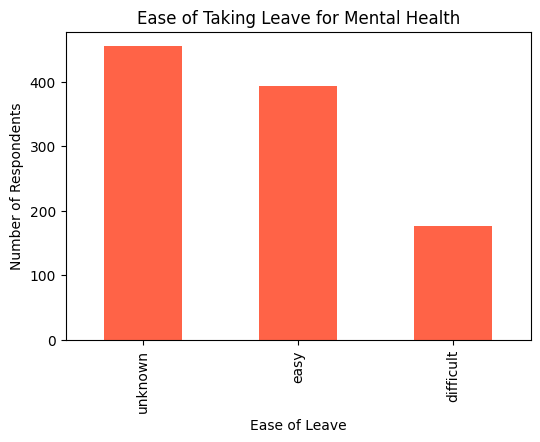

In [33]:
tech['leave'].value_counts().plot(kind='bar',color='tomato')
plt.title("Ease of Taking Leave for Mental Health")
plt.ylabel("Number of Respondents")
plt.xlabel("Ease of Leave")

<Axes: ylabel='count'>

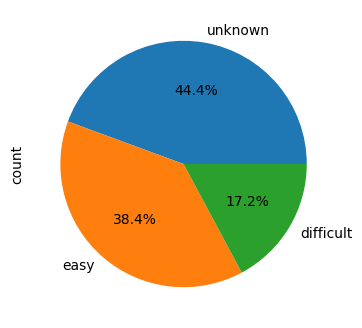

In [34]:
tech['leave'].value_counts().plot(kind='pie',autopct='%0.1f%%')

# 8.1 conclusion:
“About 45% of respondents are unsure whether they can take leave for mental health issues, indicating a lack of awareness.”

## 9 univariate analysis on benefits column:

In [35]:
tech['benefits'].value_counts()

benefits
Yes           370
Don't know    334
No            321
Name: count, dtype: int64

<Axes: xlabel='benefits'>

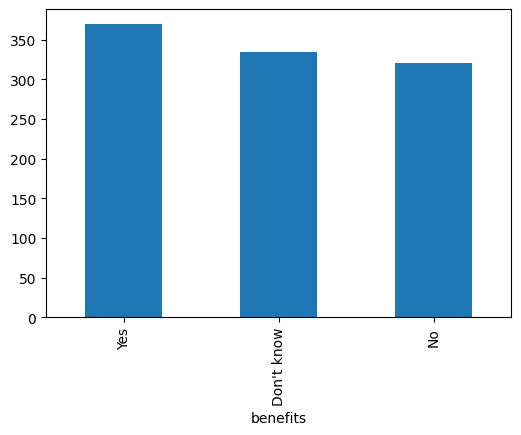

In [36]:
tech['benefits'].value_counts().plot(kind='bar')

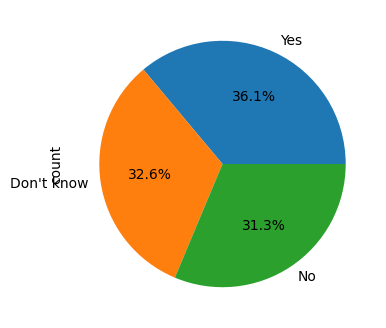

In [37]:
tech['benefits'].value_counts().plot(kind='pie',autopct='%.1f%%')
plt.show()

# 9.1 conclusion:
 Many employees are unaware of mental health benefits, suggesting a lack of transparency or poor communication from HR teams..

## 10 univariate analysis on care_options:


In [38]:
tech['care_options'].value_counts()

care_options
No          414
Yes         351
Not sure    260
Name: count, dtype: int64

lets standardize the column not sure to dont know bcs all the dataset should have standard values

In [39]:
tech['care_options']=tech['care_options'].str.replace("Not sure","Don't know")


In [40]:
tech['care_options'].value_counts()

care_options
No            414
Yes           351
Don't know    260
Name: count, dtype: int64

<Axes: xlabel='care_options'>

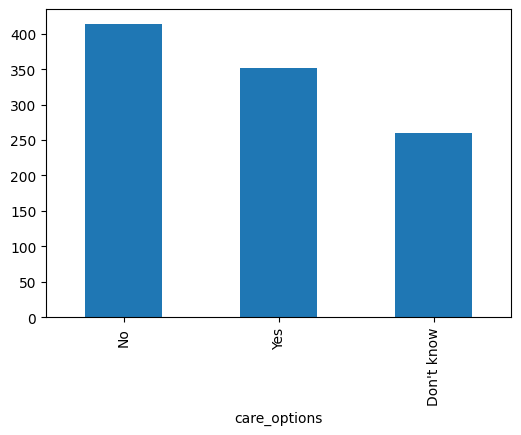

In [41]:
tech['care_options'].value_counts().plot(kind='bar')

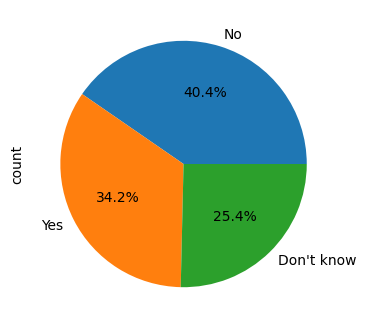

In [114]:
tech['care_options'].value_counts().plot(kind='pie',autopct='%.1f%%')


# 10.1 conclusion:
Almost 25.4 percent employees doesn't know whether they can get any type of care option from there wokplace and almost 40 percent employees doesnot get any care_

## 11 univariate analysis on mental_health_consequence:


In [43]:
tech['mental_health_consequence'].value_counts()

mental_health_consequence
No       428
Maybe    375
Yes      222
Name: count, dtype: int64

In [44]:
tech['mental_health_consequence']=tech['mental_health_consequence'].str.replace("Maybe","Don't know")

In [45]:
tech['mental_health_consequence'].value_counts()


mental_health_consequence
No            428
Don't know    375
Yes           222
Name: count, dtype: int64

<Axes: xlabel='mental_health_consequence'>

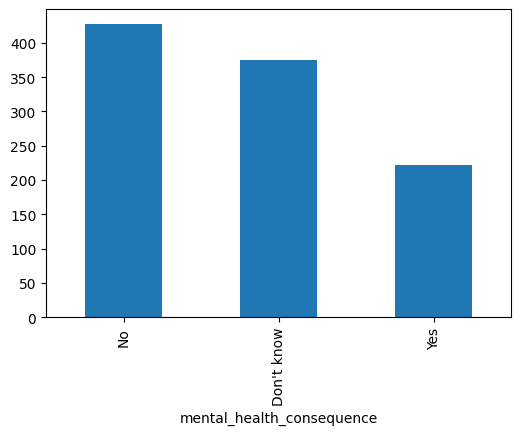

In [46]:
tech['mental_health_consequence'].value_counts().plot(kind='bar')

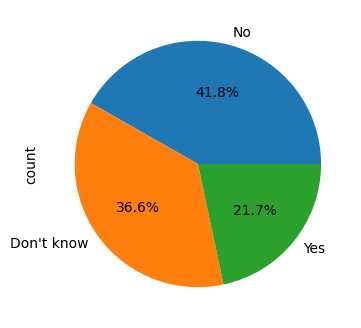

In [113]:
tech['mental_health_consequence'].value_counts().plot(kind='pie',autopct='%.1f%%')


## 11.1 conclusion:“Around 1 in 5 employees fear professional consequences if they talk about mental health at work. Employers need to actively reduce stigma and build a culture of trust and openness.”

## 12 univariate analysis on coworkers:


In [48]:
tech['coworkers'].value_counts()

coworkers
Some of them    629
No              202
Yes             194
Name: count, dtype: int64

<Axes: xlabel='coworkers'>

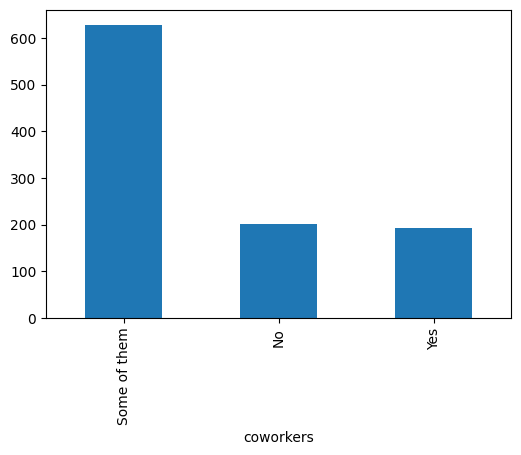

In [49]:
tech['coworkers'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

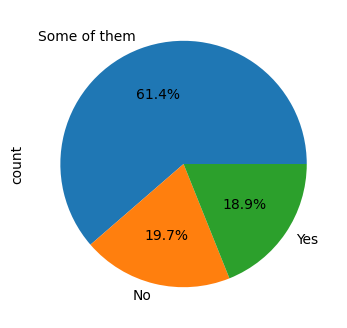

In [50]:
tech['coworkers'].value_counts().plot(kind='pie',autopct='%.1f%%')

 # 12.1 conclusion:

## 13 univariate analysis on supervisor:


In [51]:
tech['supervisor'].value_counts()

supervisor
Yes             431
No              311
Some of them    283
Name: count, dtype: int64

<Axes: xlabel='supervisor'>

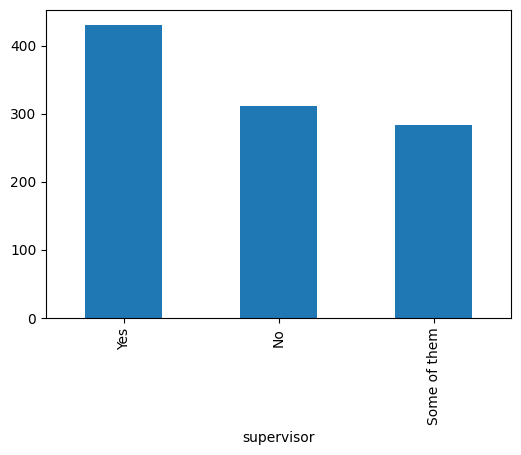

In [52]:
tech['supervisor'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

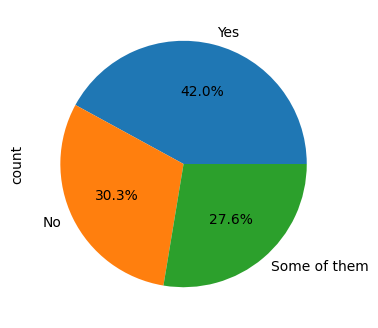

In [53]:
tech['supervisor'].value_counts().plot(kind='pie',autopct='%.1f%%')


# 13.1 conclusion :

## 14 EDA : bivariate analysis:


## 15 Bivariate analaysis on no_employees :

In [54]:
# Relationship between Gender and menta_health_status 

## 15.1 we aim to analyze how gender is associated with mental health issues in the workplaceThis will help us to understand whether certain gender are more vulnerable to mental health challenges in the tech industry.

In [55]:
tech['mental_health_num']=tech['mental_health_status'].map({'Yes':1,'No':0})

In [56]:
tech.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Age_Group,mental_health_status,mental_health_num
0,37.0,female,No,No,Yes,Often,6-25,No,Yes,Yes,...,No,Some of them,Yes,No,Maybe,Yes,No,31-40,Yes,1
1,32.0,male,No,No,No,Rarely,6-25,No,Yes,No,...,No,Yes,Yes,Yes,Yes,No,No,31-40,Yes,1
2,31.0,male,No,Yes,Yes,Often,26-100,No,Yes,No,...,Yes,Some of them,No,Maybe,Maybe,No,Yes,31-40,Yes,1
3,31.0,male,No,No,No,Never,100-500,Yes,Yes,Yes,...,No,Some of them,Yes,Yes,Yes,Don't know,No,31-40,Yes,1
4,33.0,male,No,Yes,No,Sometimes,6-25,No,Yes,Yes,...,No,Yes,Yes,No,Maybe,Don't know,No,31-40,Yes,1


TypeError: 'str' object is not callable

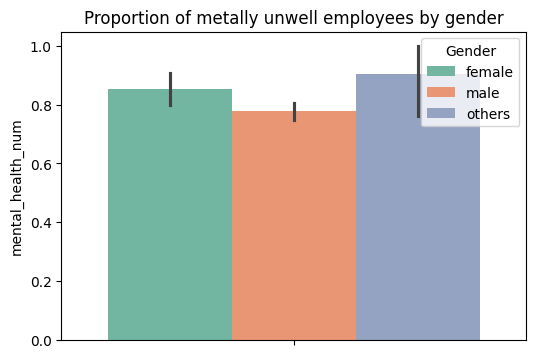

In [110]:
import seaborn as sns;
sns.barplot(data=tech,hue='Gender',y='mental_health_num',palette='Set2')
plt.title('Proportion of metally unwell employees by gender')
plt.xlabel('Gender')
plt.ylabel('Proportion mentally unwell')


C:\Users\91830\AppData\Local\Temp\ipykernel_37300\1125703623.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_group, x='Gender', y='mental_health_num', palette='pastel')


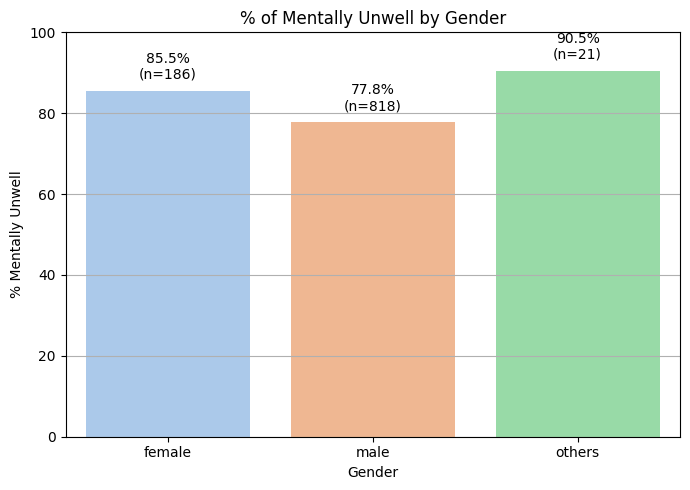

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Step 2: Group by gender and calculate mean (as %)
gender_group = tech.groupby('Gender')['mental_health_num'].mean().reset_index()
gender_group['mental_health_num'] *= 100  # Convert to percentage
gender_group.head()
# Step 3: Create the barplot
plt.figure(figsize=(7,5))
ax = sns.barplot(data=gender_group, x='Gender', y='mental_health_num', palette='pastel')
plt.title('% of Mentally Unwell by Gender')
plt.xlabel('Gender')
plt.ylabel('% Mentally Unwell')
plt.ylim(0, 100)
plt.grid(axis='y')

# Step 4: Add percentage + sample size (n) labels above bars
for index, row in gender_group.iterrows():
    gender = row['Gender']
    count = tech[tech['Gender'] == gender].shape[0]
    percent = row['mental_health_num']
    
    # Label text: "43.5% (n=300)"
    label = f"{percent:.1f}%\n(n={count})"
    
    ax.text(index, percent + 3, label, ha='center', fontsize=10)

plt.tight_layout()
plt.show()




📌 **Key Insight:** _(Write your observation here)_

In [59]:
data=pd.crosstab(tech['mental_health_num'],tech['Gender'],normalize='columns')*100
data


Gender,female,male,others
mental_health_num,,,
0,14.516129,22.249389,9.52381
1,85.483871,77.750611,90.47619


<Axes: xlabel='Gender', ylabel='mental_health_num'>

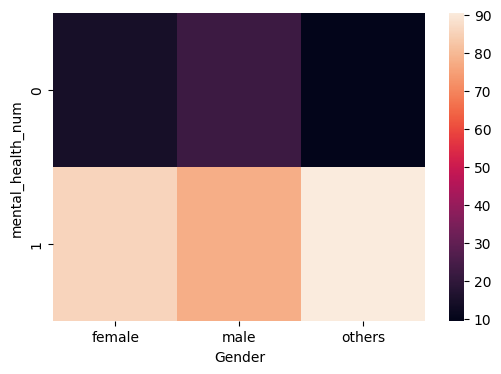

In [60]:
sns.heatmap(pd.crosstab(tech['mental_health_num'],tech['Gender'],normalize='columns')*100)

# 15.2 conclusion
The female and other gender has high percentage of mentally unwell indviduals however the others group has very small sample size which may exaggerate the percentage.

## 16 Bivariate analaysis on no_employees :

In [61]:
##  Relationship between self_employeed and mental_health_status:

## 16.1 We aim to analyze Does the nature of work affect the way people face and deal with their mental health
Lets see how the nature of work affects the way employees respond to mental health issues. We divide this into three catgeories
Self-Employment
Remote-work
Organization Size that is no_of_employees5
We will analyze their impacts on the mental health of employees and the way they respond to it step by step

In [62]:
data=pd.crosstab(tech['mental_health_status'],tech['self_employed'],normalize='columns')*100
data

self_employed,No,Yes
mental_health_status,,
No,21.404682,14.84375
Yes,78.595318,85.15625


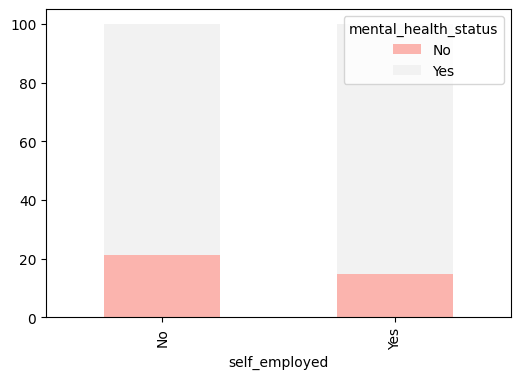

In [111]:
data=pd.crosstab(tech['self_employed'],tech['mental_health_status'],normalize='index')*100
data.plot(kind='bar',stacked=True,colormap='Pastel1')


# 16.2 conclusion:
Among self employed indviduals only 14 percent are mentally well while  85 percent are mentally unwell so it concludes that self employed indviduals are more likely to be mentally unwell

## 17 Bivariate analaysis on no_employees :

In [64]:
## Relationship between mental_health_status and no_employees

## 17.1 we aim to analyze how the size of company is associated with mental health issues ,This will help us to understand whether large scale companies or small startups and companies  are more vulnerable to mental health challenges in the tech industry.

In [65]:
data=pd.crosstab(tech['mental_health_status'],tech['no_employees'],normalize='columns')*100
data

no_employees,1-5,100-500,26-100,500-1000,6-25,More than 1000
mental_health_status,,,,,,
No,12.837838,20.0,21.07438,24.390244,24.719101,19.791667
Yes,87.162162,80.0,78.92562,75.609756,75.280899,80.208333


<Axes: xlabel='no_employees', ylabel='mental_health_status'>

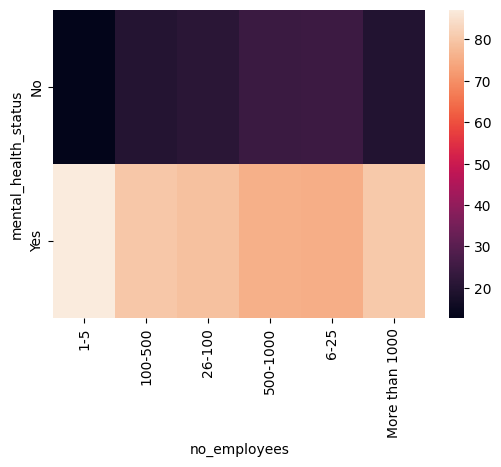

In [66]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['no_employees'],normalize='columns')*100)


# 17.2 conclusion:
In small companies (1-5 employees) are more likely to be mentally unwell as compared to big and large companies.

## 18  Bivariate analysis on Benefits

In [67]:
## Relationship between mental_health_status and Remote_work

## 18.1 we aim to analyze how type of workmode is associated with mental health issues in the workplace.This will help us to understand whether remote work are more vulnerable to mental health challenges in the tech industry.

In [68]:
data=pd.crosstab(tech['mental_health_status'],tech['remote_work'],normalize='columns')*100
data

remote_work,No,Yes
mental_health_status,,
No,21.242775,19.219219
Yes,78.757225,80.780781


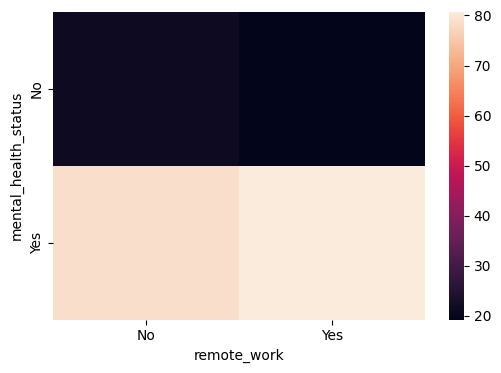

In [112]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['remote_work'],normalize='columns')*100)


# 18.2 conclusion:
Mental health issues are reported at a similar rate among remote (80.8%) and non-remote workers (78.8%), showing remote work doesn't significantly impact mental health.

## 19 Bivariate analysis on Benefits

In [70]:
## Relationship between mental_health_status and Benefits

## 19.1 we aim to analyze how  benefits given to employee is associated with mental health issues .This will help us to understand whether facilities focussed workplace  are less vulnerable to mental health challenges or not  in the tech industry.

In [71]:
data=pd.crosstab(tech['mental_health_status'],tech['benefits'],normalize='columns')*100
data

benefits,Don't know,No,Yes
mental_health_status,,,
No,27.844311,20.872274,13.783784
Yes,72.155689,79.127726,86.216216


<Axes: xlabel='benefits', ylabel='mental_health_status'>

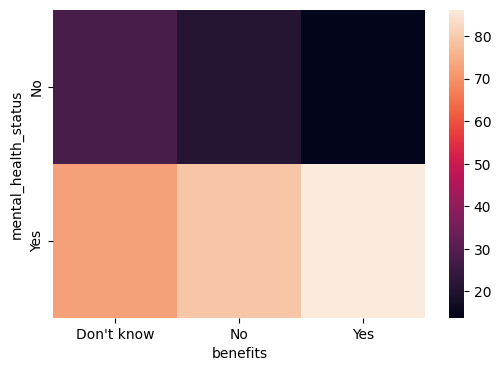

In [72]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['benefits'],normalize='columns')*100)

<Axes: xlabel='benefits', ylabel='count'>

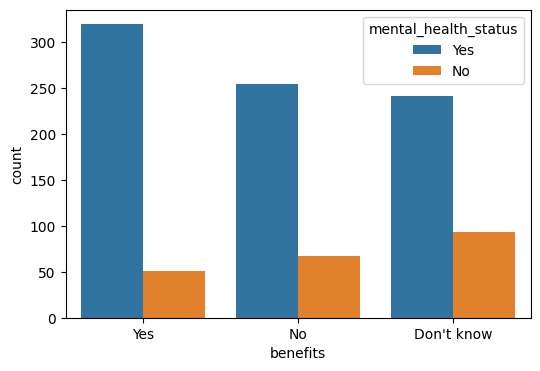

In [73]:
sns.countplot(data=tech,x='benefits',hue='mental_health_status')

# 19.2 conclusion:
Most of the individuals with mental health condition knows about the benefits given to them. 

## 20 Bivariate analysis on care_option

In [74]:
## Relationship between mental_health_status and care_option

## 20.1 we aim to analyze how care_option given to employee is associated with mental health issues .This will help us to understand whether facilities focussed workplace  are less vulnerable to mental health challenges or not  in the tech industry.

<Axes: xlabel='care_options', ylabel='mental_health_status'>

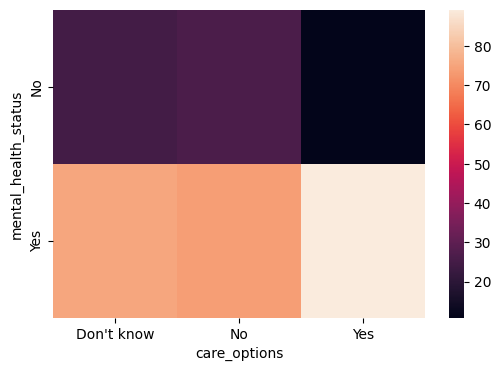

In [75]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['care_options'],normalize='columns')*100)

In [76]:
data=pd.crosstab(tech['mental_health_status'],tech['care_options'],normalize='columns')*100
data

care_options,Don't know,No,Yes
mental_health_status,,,
No,24.615385,26.328502,10.826211
Yes,75.384615,73.671498,89.173789


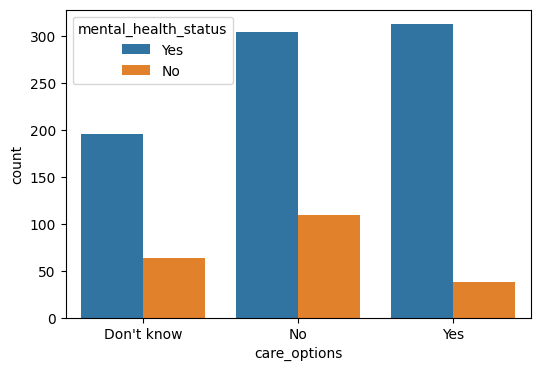

In [77]:
sns.countplot(data=tech,x='care_options',hue='mental_health_status')
plt.xlabel='care_options'
plt.ylabel='count'
plt.savefig('mental_health_status.png')

# 20.2conclusion:
Most individuals with mental health condition knows and have access to  care_options but also almost same number of indviduals lack knowledge about care_options.

## 21 Bivariate analysis on wellness program

In [78]:
## Relationship between mental_health_status and wellness program

## 21.1 we aim to analyze how wellnes program  given to employee is associated with mental health issues .This will help us to understand whether facilities focussed workplace  are less vulnerable to mental health challenges or not  in the tech industry.

In [79]:
data=pd.crosstab(tech['mental_health_status'],tech['wellness_program'],normalize='columns')*100


<Axes: xlabel='wellness_program', ylabel='mental_health_status'>

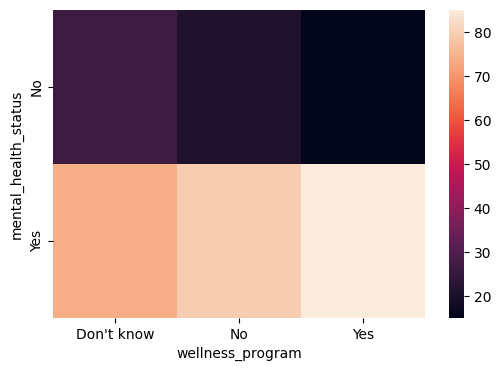

In [80]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['wellness_program'],normalize='columns')*100)

# 21.2 conclusion:
A high percentage of people who dont know about wellness program are those who dont have mental health issues,and also a high percentage of people who knows about welness program are more likely to be mentally affected.

## 22 Bivariate analysis on seek help

In [81]:
## Relationship between mental_health_status and seek help

## 22.1 "To examine whether the availability of mental health help resources at the workplace is associated with the mental health status of employees."

In [82]:
 tech['seek_help'].value_counts()

seek_help
No            550
Don't know    296
Yes           179
Name: count, dtype: int64

<Axes: xlabel='seek_help', ylabel='count'>

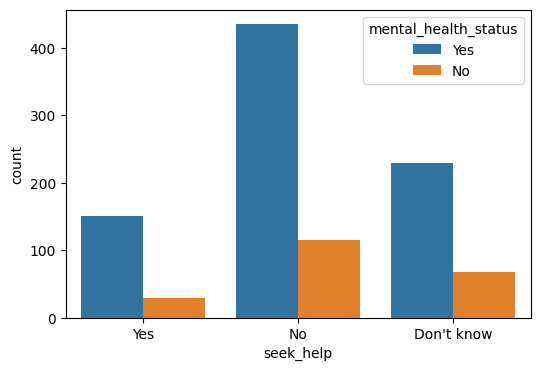

In [83]:
sns.countplot(data=tech,x='seek_help',hue='mental_health_status')

# 22.2 conclusion:
Most of the employees who does not have access to mental health resources and are more likely to have poor mental health .In contrast the employees who have access to mental health resources are more likely to have good mental health.

## 23 Bivariate analysis on leave

In [84]:
## Relationship between mental_health_status and leave

## 23.1 "To examine whether the ease of leave for mental health issue  at the workplace is associated with the mental health status of employees."

Text(0.5, 1.0, 'access to leave vs mental health')

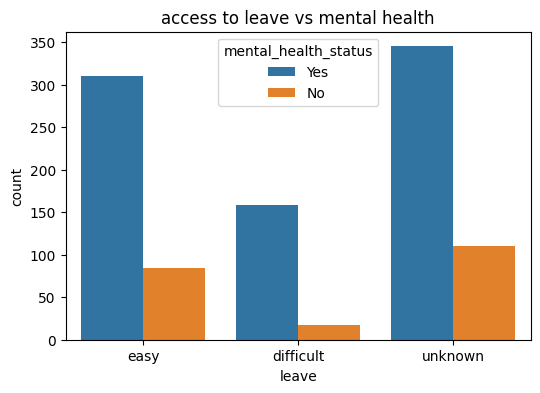

In [85]:
sns.countplot(data=tech,x='leave',hue='mental_health_status')
plt.title('access to leave vs mental health')

# 23.2 conclusion:
Most of the employees even dont know whether they can get leave for mental health issues and they are more likely to be mentally unwell that shows lack of awareness in that regards.

## 24 Bivariate analysis on coworkers

In [86]:
## Relationship between mental_health_status and coworkers

## 24.1 "To examine whether the openess with coworkers regarding mental health issues is associated with the mental health status of employees."

In [87]:
tech['coworkers'].value_counts()

coworkers
Some of them    629
No              202
Yes             194
Name: count, dtype: int64

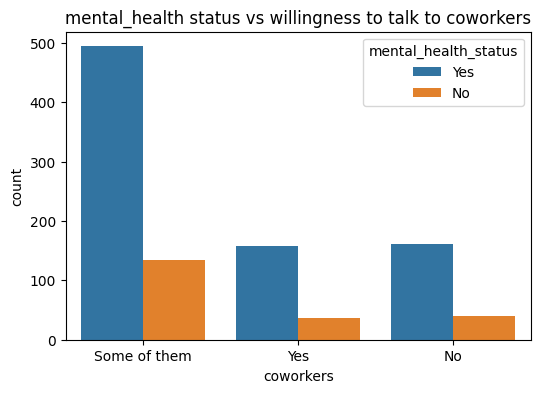

In [88]:
sns.countplot(data=tech,x='coworkers',hue='mental_health_status')
plt.title('mental_health status vs willingness to talk to coworkers')
plt.savefig('mental.png')

# 24.2 conclusion:
A large number of employees who are mentally unwell are more tend to talk to some coworkers rather than all or none.

## 25 Bivariate analysis on  mental_health_consequence

In [89]:
## Relationship between mental_health_status and  mental_health_consequence

## 25.1 "To analyze that discussing a mental health issue with your employer would have negative consequences"

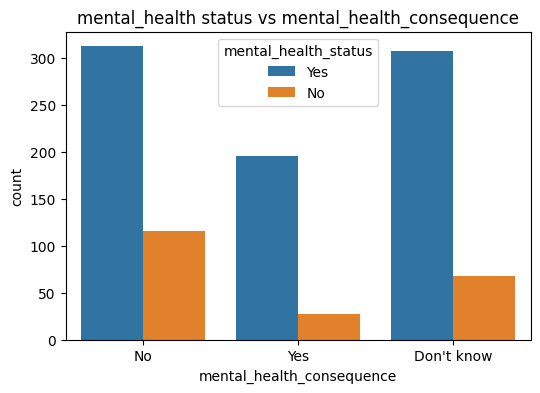

In [106]:
sns.countplot(data=tech,x='mental_health_consequence',hue='mental_health_status')
plt.title('mental_health status vs mental_health_consequence')
plt.savefig('mental.png')

In [91]:
pd.crosstab(tech['mental_health_status'],tech['mental_health_consequence'],normalize='index')*100

mental_health_consequence,Don't know,No,Yes
mental_health_status,,,
No,32.227488,54.976303,12.796209
Yes,37.714988,38.329238,23.955774


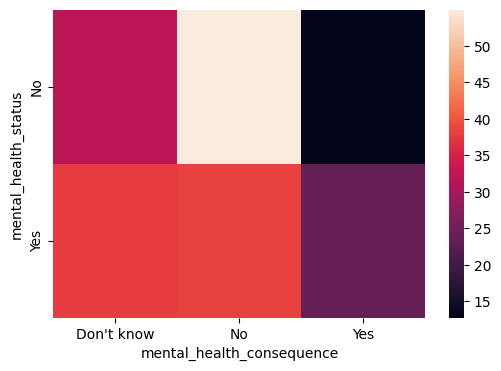

In [109]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['mental_health_consequence'],normalize='index')*100)
plt.savefig('mental1.png')


# 25.2 conclusion:
Among those who reported having mental health issues only 23 percent  are those who think that it led to negative impact at work.

## 26 Bivariate analysis on supervisor

In [93]:
## Relationship between mental_health_status and  supervisor

## 26.1 "To examine whether the openess with supervisor regarding mental health issues is associated with the mental health status of employees."

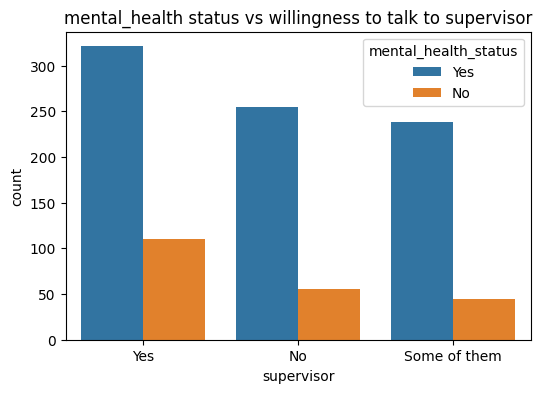

In [108]:
sns.countplot(data=tech,x='supervisor',hue='mental_health_status')
plt.title('mental_health status vs willingness to talk to supervisor')


In [95]:
pd.crosstab(tech['mental_health_status'],tech['supervisor'],normalize='index')*100

supervisor,No,Some of them,Yes
mental_health_status,,,
No,26.540284,21.327014,52.132701
Yes,31.326781,29.238329,39.434889


<Axes: xlabel='supervisor', ylabel='mental_health_status'>

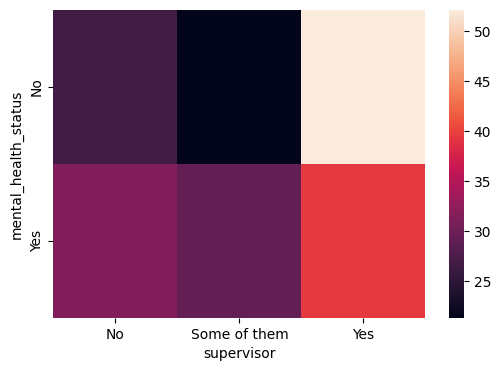

In [96]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['supervisor'],normalize='index')*100)

# 26.2 conclusion:
A large number of employees who are mentally well are more tend to talk to supervisor as compared to those who are mentally unwell.


## 27 Bivariate analysis on menta_health_interview

In [97]:
## Relationship between mental_health_status and  supervisor

## 27.1 "To examine whether the openess of discussing mental health problem in interviews is associated with the mental health status of employees."

In [98]:
tech['mental_health_interview'].value_counts()

mental_health_interview
No       806
Maybe    182
Yes       37
Name: count, dtype: int64

<Axes: xlabel='mental_health_interview', ylabel='count'>

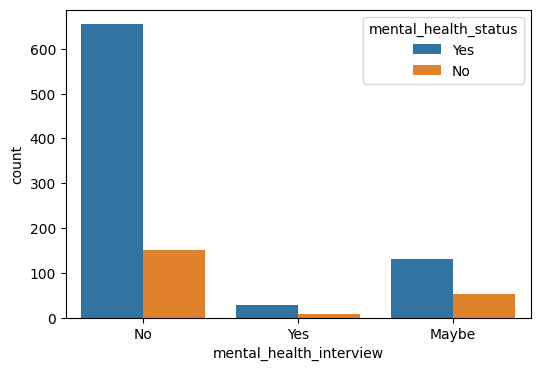

In [99]:
sns.countplot(data=tech,x='mental_health_interview',hue='mental_health_status')

# 27.2 conclusion:
A large number of employees does not prefer discussing mental health problems in interview even if they are mentally unwell which specify that there is lack of awareness and hesitation among them.

## 28 Bivariate analysis on mental_vs_physical

In [100]:
## Relationship between mental_health_status and mental_vs_physical

## 28.1 "To examine whether the employer take mental health as serious as physical  is associated with the mental health status of employees."

In [101]:
tech['mental_vs_physical'].value_counts()

mental_vs_physical
Don't know    478
Yes           295
No            252
Name: count, dtype: int64

<Axes: xlabel='mental_vs_physical', ylabel='mental_health_status'>

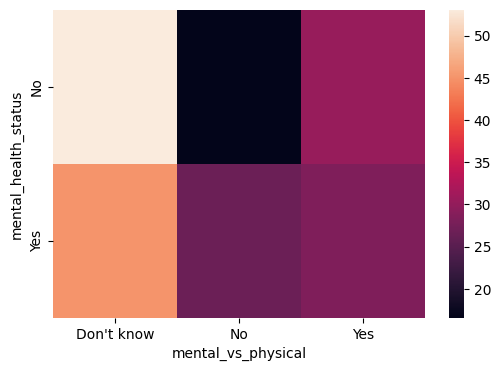

In [102]:
sns.heatmap(pd.crosstab(tech['mental_health_status'],tech['mental_vs_physical'],normalize='index')*100)

# 28.2 conclusion:
The employees who are mentally unwell even dont know whether both mental and physical health are important or not.

## 29🌟 Openness in the Working Environment

### 🧠 Why Measure Openness?
A psychologically safe workplace encourages employees to seek help, discuss concerns with supervisors or coworkers, and be open about mental health challenges without fear of stigma. This "Openness Index" aims to quantify how culturally safe employees feel in their work environment.

---

### 📊 How We Created the Openness Index
We combined four key survey factors to create a composite score:  

1. **Seek Help**: Whether employees feel comfortable seeking help for mental health concerns.  
2. **Coworker Openness**: If they can discuss mental health with colleagues.  
3. **Supervisor Openness**: If they feel safe talking about mental health with managers.  
4. **Mental Health Interview**: Whether they are comfortable being asked about mental health during interviews.

Each positive response contributes 1 point to the index (max score = 4):  

- 🟢 **High Openness (3–4 points)**: Employees feel safe discussing mental health in their workplace.  
- 🟡 **Moderate Openness (1.5–2 points)**: Some barriers exist to open communication.  
- 🔴 **Low Openness (0 points)**: Employees do not feel comfortable talking about mental health.

---

### 💡 Business Objective
This analysis helps us understand whether workplace culture supports mental health discussions and how this correlates with **employee productivity** and **work interference**.

---



In [103]:
def coworkerandsupervisor(value):
    value = value.strip().lower()
    if(value)=='yes':
        return 1
    elif(value)=='some of them':
        return 0.5
    else:
        return 0
        
def map_openness(value):
    if value.strip().lower() == 'yes':
        return 1
    elif value=='maybe':
        return 0.5
    else:
        return 0 

In [104]:
tech['seek_help_score']=tech['seek_help'].apply(map_openness)
tech['supervisor_score']=tech['supervisor'].apply(coworkerandsupervisor)
tech['coworker_score']=tech['coworkers'].apply(coworkerandsupervisor)
tech['mental_health_interview_score']=tech['mental_health_interview'].apply(map_openness)

C:\Users\91830\AppData\Local\Temp\ipykernel_37300\3407150770.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='openness_category', data=tech, palette='coolwarm')


TypeError: 'str' object is not callable

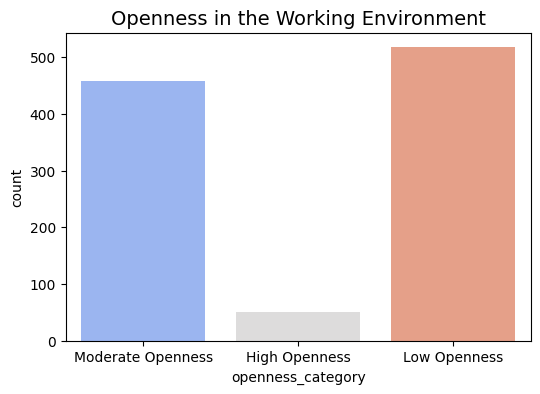

In [105]:
tech['openness_score'] = (
    tech['seek_help_score'] + 
    tech['coworker_score'] + 
    tech['supervisor_score'] + 
    tech['mental_health_interview_score']
)
def categorize_openness(score):
    if score >= 3:
        return 'High Openness'
    elif score >= 1.5:
        return 'Moderate Openness'
    else:
        return 'Low Openness'

tech['openness_category'] = tech['openness_score'].apply(categorize_openness)

sns.countplot(x='openness_category', data=tech, palette='coolwarm')
plt.title('Openness in the Working Environment', fontsize=14)
plt.xlabel('Openness Level')
plt.ylabel('Number of Employees')
plt.show()


### conclusion:
This graph shows that in tech industry there are very less employees who are highly open about the mental health issue.

## 30 Bivariate analysis on openness level with work interfere

## 30.1 "To examine whether employees feel their mental health interferes with their work"

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='openness_category', hue='work_interfere', data=tech, palette='Set2')
plt.title('Openness Level vs Work Interference', fontsize=14)
plt.xlabel('Openness Level')
plt.ylabel('Number of Employees')
plt.legend(title='Work Interference')
plt.show()


## 30.2 conclusion:
Employees in low-openness environments report substantially higher work interference due to mental health challenges.In contrast, those in high-openness workplaces are far less likely to face productivity issues, with most reporting “Never” or “No Issue”.

## 31 🌟 Impact of Mental Health Support Services
### 🧠 Why Measure Mental Health Services?
While cultural openness fosters communication, the actual support services provided by a company directly affect how employees manage mental health challenges. These include access to professional care, mental health benefits, leave policies, and proactive wellness programs. Together, these offerings reflect an organization’s investment in employee well-being.

In this section, we build a "Services Support Index" to quantify how supportive the company environment is in terms of mental health infrastructure.

### 📊 How We Created the Services Support Index
We combined four service-related variables to generate a composite score:

1. **Mental Health Benefits** : Are mental health care expenses covered by the employer?
2. **Care Options**: Does the company offer options for mental health treatment?
3. **Leave Policy**: Is the mental health leave policy supportive and flexible?
4. **Wellness Program**: Are wellness initiatives provided that promote mental well-being?

Each favorable response (e.g., “Yes”) contributes to a higher Services Score.

Based on the score, we categorize companies as:

_🟢 **High Support (3–4 points)**: Strong infrastructure for mental health services

_🟡 **Moderate Support (1.5–2 points)**: Some support exists but may lack consistency

_🔴 **Low Support (0–1 point)**: Minimal or no formal support structures in place

### 💡 Business Objective
This analysis evaluates how the presence (or absence) of mental health services impacts **employee performance**, using **work interference** as a proxy for reduced productivity. 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🟢 STEP 1: Define mapping function for each service-related feature
def map_services(value):
    if value == 'Yes'or value=='easy':
        return 1
    elif value == 'Some of them' or value == 'Don’t know':
        return 0.5
    else:
        return 0
tech['benefits_score'] = tech['benefits'].apply(map_services)
tech['care_options_score'] = tech['care_options'].apply(map_services)
tech['leave_score'] = tech['leave'].apply(map_services)
tech['wellness_program_score'] = tech['wellness_program'].apply(map_services)

tech['services_score'] = (
    tech['benefits_score'] +
    tech['care_options_score'] +
    tech['leave_score'] +
    tech['wellness_program_score']
)


def categorize_services(score):
    if score >= 3:
        return 'High Support'
    elif score >= 1.5:
        return 'Moderate Support'
    else:
        return 'Low Support'

tech['services_category'] = tech['services_score'].apply(categorize_services)



In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='services_category', data=tech, palette='viridis')
plt.title('Distribution of Mental Health Services Support Level', fontsize=14)
plt.xlabel('Support Level')
plt.ylabel('Number of Employees')
plt.show()

### conclusion:
This graph shows that in tech industry there is very lack of mental health support services.

## 31 Bivariate analysis on Mental Health Services Support with  Work Interference

## 31.1 "To examine whether employees feel their mental health interferes with their work"

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='services_category', hue='work_interfere', data=tech, palette='Set2')
plt.title('Mental Health Services Support vs Work Interference')
plt.xlabel('Services Support Level')
plt.ylabel('Number of Employees')
plt.legend(title='Work Interference')
plt.show()

### conclusion:
Low Support: While “Sometimes” dominates, there’s a notable rise in “No Issue” and “Never” interference — possibly due to underreporting or lack of awareness, not actual well-being.
Moderate Support: A balanced distribution follows, with “Rarely” and “No Issue” showing improved outcomes.
High Support: Although “Sometimes” remains highest, the presence of “Rarely” becomes more prominent — and “Often” becomes minimal — suggesting better mitigation of mental health challenges.


## 🛠️ Tools Used
- Python (Pandas, Matplotlib, Seaborn)
- Jupyter Notebook